In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

xlsx_file = "alimarko_vs_vhg_contig_blast.xlsx"

df = pd.read_excel(xlsx_file)

print(df.shape)
df.head()

(1195, 14)


,VHG контиг,"Длина контига VHG, нукл.",AliMarko контиг,"Длина контига AliMarko, нукл.",Начало контига VHG,Конец контига VHG,Начало контига AliMarko,Конец контига AliMarko,"Длина выравнивания, нукл.","Процент идентичности, %","Покрытие контига VHG, %",Мисматчей,Открытие гэпа,Битскор
0,SRR14381429_cap3_Contig-2,10510,k141_18829,9310,1,135,135,1,135,100.0,1,0,0,250.0
1,SRR14381429_cap3_Contig-4,7738,k141_14601,8438,7675,7738,6723,6660,64,100.0,1,0,0,119.0
2,SRR14381429_cap3_Contig-10,5586,k141_9267,5555,1,5555,1,5555,5555,100.0,99,0,0,10259.0
3,SRR14381429_cap3_Contig-14,4630,k141_16661,6888,48,80,43,75,33,100.0,1,0,0,62.1
4,SRR14381429_cap3_Contig-16,4492,k141_17975,7045,1,4492,6793,2302,4492,100.0,100,0,0,8296.0


In [3]:
# Покрытие AliMarko

df["Покрытие контига AliMarko, %"] = (
    (df["Конец контига AliMarko"] - df["Начало контига AliMarko"]).abs() + 1
) / df["Длина контига AliMarko, нукл."] * 100

# сортировка:
# 1) identity по убыванию
# 2) покрытие AliMarko по убыванию

df_best = (
    df.sort_values(
        ["Процент идентичности, %", "Покрытие контига VHG, %"],
        ascending=False
    )
    .drop_duplicates(subset="VHG контиг", keep="first")
    .reset_index(drop=True)
)

print("Исходных строк:", len(df))
print("Лучших хитов:", len(df_best))

df_best.head()

Исходных строк: 1195
Лучших хитов: 195


,VHG контиг,"Длина контига VHG, нукл.",AliMarko контиг,"Длина контига AliMarko, нукл.",Начало контига VHG,Конец контига VHG,Начало контига AliMarko,Конец контига AliMarko,"Длина выравнивания, нукл.","Процент идентичности, %","Покрытие контига VHG, %",Мисматчей,Открытие гэпа,Битскор,"Покрытие контига AliMarko, %"
0,SRR14381429_cap3_Contig-16,4492,k141_17975,7045,1,4492,6793,2302,4492,100.0,100,0,0,8296.0,63.761533
1,SRR14381429_cap3_Contig-37,2682,k141_13160,2837,1,2682,2682,1,2682,100.0,100,0,0,4953.0,94.536482
2,SRR14381429_cap3_Contig-41,2450,k141_14709,3436,1,2450,987,3436,2450,100.0,100,0,0,4525.0,71.303842
3,SRR14381429_cap3_Contig-47,2217,k141_16661,6888,1,2217,5324,3108,2217,100.0,100,0,0,4095.0,32.186411
4,SRR14381429_cap3_Contig-56,1794,k141_35630,1794,1,1794,1794,1,1794,100.0,100,0,0,3314.0,100.000000


In [4]:
df_best.to_excel(
    "alimarko_vs_vhg_best_hits.xlsx",
    index=False
)

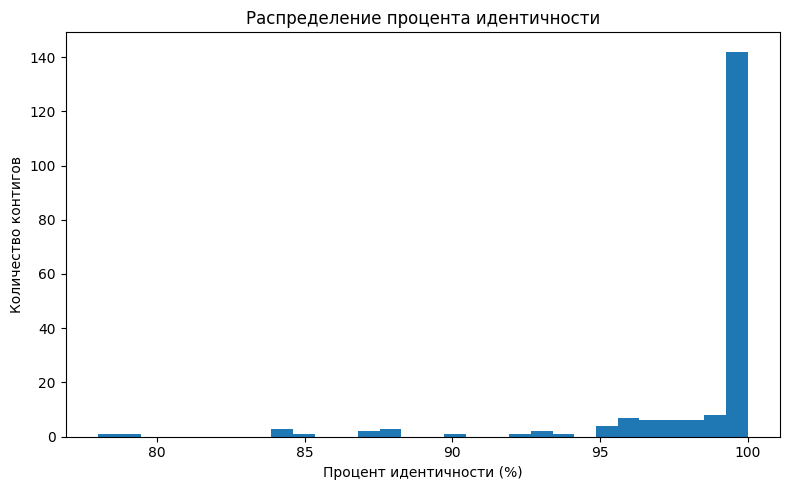

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_best["Процент идентичности, %"],
    bins=30
)

plt.xlabel("Процент идентичности (%)")
plt.ylabel("Количество контигов")
plt.title("Распределение процента идентичности")

plt.tight_layout()
plt.show()

In [7]:
from Bio import SeqIO

vhg_ids = set(df_best["VHG контиг"])

input_fasta = "VHG_SRR14381429_contigs.fasta"
output_fasta = "VHG_SRR14381429_contigs_filtered.fasta"

records = (
    rec for rec in SeqIO.parse(input_fasta, "fasta")
    if rec.id in vhg_ids
)

count = SeqIO.write(records, output_fasta, "fasta")

print("Сохранено VHG контигов:", count)

Сохранено VHG контигов: 195


In [8]:
alimarko_ids = set(df_best["AliMarko контиг"])

input_fasta = "alimarko_SRR14381429_contigs.fasta"
output_fasta = "alimarko_SRR14381429_contigs_filtered.fasta"

records = (
    rec for rec in SeqIO.parse(input_fasta, "fasta")
    if rec.id in alimarko_ids
)

count = SeqIO.write(records, output_fasta, "fasta")

print("Сохранено AliMarko контигов:", count)

Сохранено AliMarko контигов: 144


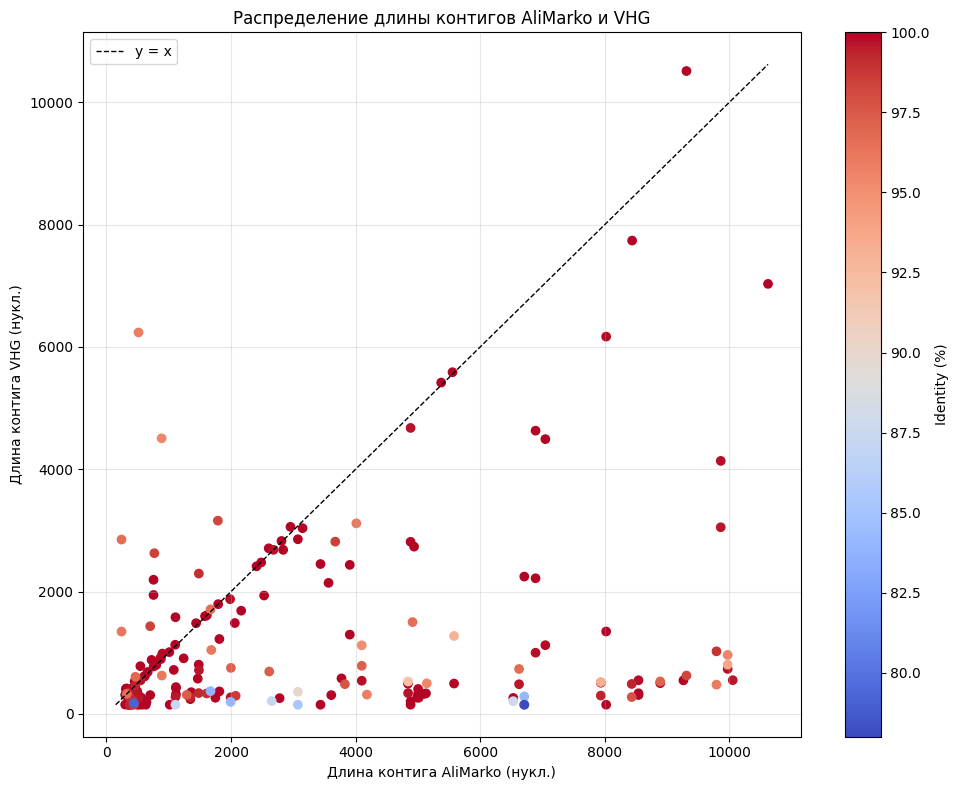

In [9]:
plt.figure(figsize=(10, 8))

sc = plt.scatter(
    df_best["Длина контига AliMarko, нукл."],
    df_best["Длина контига VHG, нукл."],
    c=df_best["Процент идентичности, %"],
    cmap="coolwarm",
    alpha=1.0
)

xmin = min(
    df_best["Длина контига AliMarko, нукл."].min(),
    df_best["Длина контига VHG, нукл."].min()
)

xmax = max(
    df_best["Длина контига AliMarko, нукл."].max(),
    df_best["Длина контига VHG, нукл."].max()
)

plt.plot(
    [xmin, xmax],
    [xmin, xmax],
    "--",
    color="black",
    linewidth=1,
    label="y = x"
)

cbar = plt.colorbar(sc)
cbar.set_label("Identity (%)")

plt.xlabel("Длина контига AliMarko (нукл.)")
plt.ylabel("Длина контига VHG (нукл.)")

plt.title("Распределение длины контигов AliMarko и VHG")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()